In [1]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

np.random.seed(0)

data_name_german = 'german'
times_cte_info_path_german = f'../metadata/german/cte_shap_sage_times_0_3.csv'

data_name_compas = 'compas'
times_cte_info_path_compas = f'../metadata/compas/cte_shap_sage_times_0_3.csv'

In [2]:
times_cte_info_german = pd.read_csv(times_cte_info_path_german)
times_cte_info_german['explanation'] = times_cte_info_german['method'].str.extract(r'_(shap|sage)')
times_cte_info_german['method'] = times_cte_info_german['method'].str.replace(r'_(shap|sage)', '', regex=True)
times_cte_info_compas = pd.read_csv(times_cte_info_path_compas)
times_cte_info_compas['explanation'] = times_cte_info_compas['method'].str.extract(r'_(shap|sage)')
times_cte_info_compas['method'] = times_cte_info_compas['method'].str.replace(r'_(shap|sage)', '', regex=True)

In [3]:
times_cte_info_compas

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,mmd,mae,top_k,explanation
0,compas,0,cte,26.066775,0.023326,1235,32,0.000165,0.003135,0.6,shap
1,compas,0,cte,209.843833,0.023326,1235,32,0.000165,0.012333,1.0,sage
2,compas,0,iid,26.102992,0.000053,1235,32,0.002250,0.005585,0.6,shap
3,compas,0,iid,270.357186,0.000053,1235,32,0.002250,0.010399,1.0,sage
4,compas,0,cte_stratified_real,19.783355,0.001003,1235,24,0.001249,0.015647,0.6,shap
5,compas,0,cte_stratified_real,147.557878,0.001003,1235,24,0.001249,0.008725,1.0,sage
6,compas,0,cte_stratified_pred,32.056595,0.012220,1235,40,0.001156,0.012770,0.6,shap
7,compas,0,cte_stratified_pred,258.477075,0.012220,1235,40,0.001156,0.005390,0.8,sage
8,compas,0,cte_with_predictions,25.732460,0.012531,1235,32,0.000060,0.004999,0.6,shap
9,compas,0,cte_with_predictions,165.608420,0.012531,1235,32,0.000060,0.010930,1.0,sage


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def preprocess_data(data):
    data = data[data['method'] != 'cte_stratified_real']
    data['method'] = data['method'].replace({
        'cte_stratified_pred': 'cte stratified',
        'cte_with_predictions': 'cte with predictions'
    })
    data['explanation'] = data['explanation'].replace({
        'shap': 'Kernel SHAP',
        'sage': 'Permutation SAGE'
    })
    explanation_order = ['Kernel SHAP', 'Permutation SAGE']
    data['explanation'] = pd.Categorical(data['explanation'], categories=explanation_order, ordered=True)

    return data


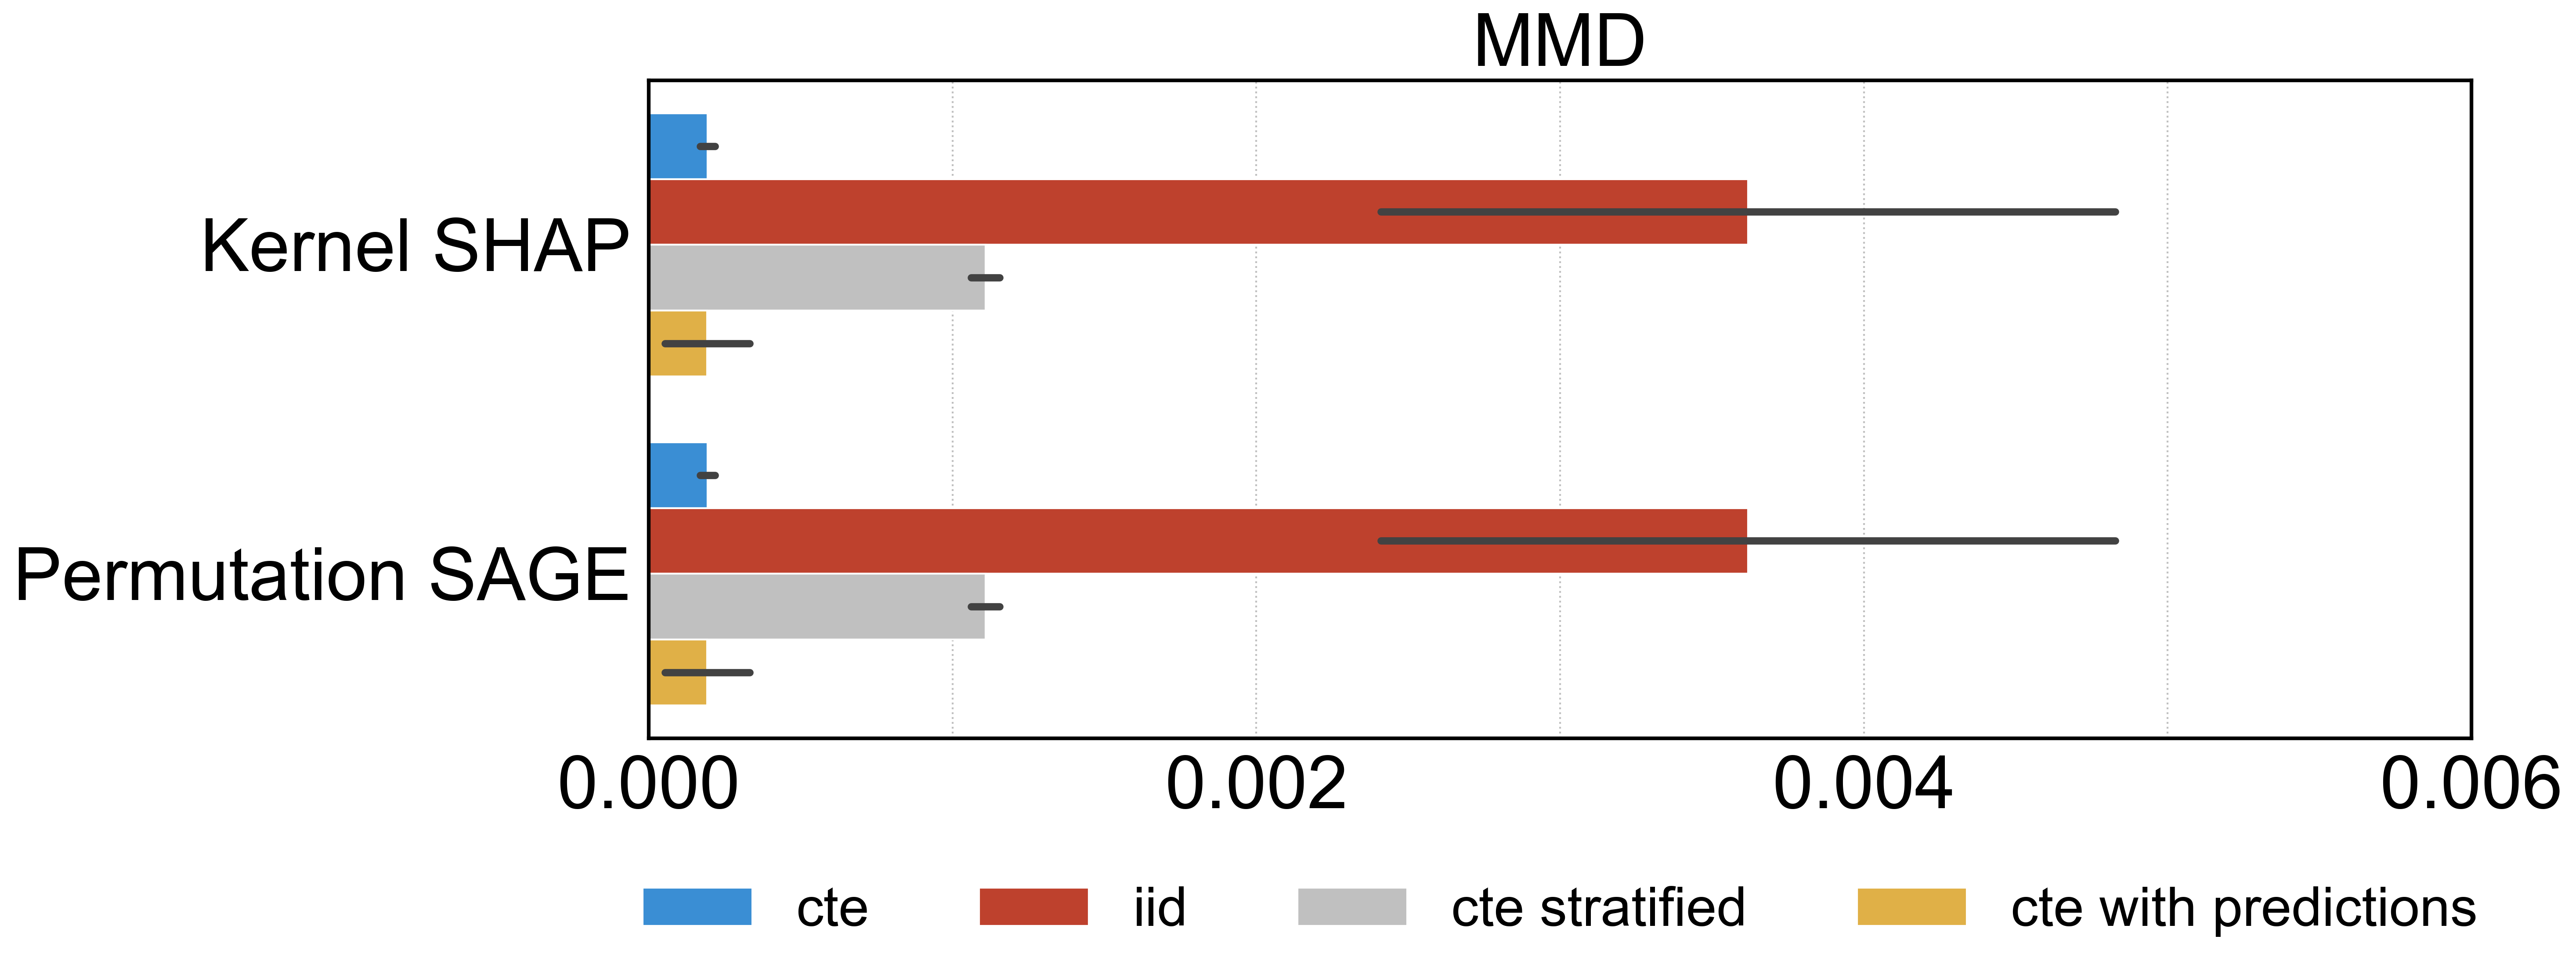

In [ ]:
plot_data = preprocess_data(times_cte_info_compas)

custom_palette = {
    'cte': '#2191ed',                
    'iid': '#d62f15',                   
    'cte stratified': '#c0c0c0',        
    'cte with predictions': '#fab92d',  
}
sns.set_context("notebook", font_scale=2)
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.8)
sns.set_style("white")  # White background
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["axes.edgecolor"] = "black"
plt.figure(figsize=(20, 8), dpi=300)
ax = sns.barplot(
    y="explanation", x="mmd", hue="method", data=plot_data,
    palette=custom_palette, errorbar="sd", zorder=2, errwidth=4
)

ax.set_title("MMD", fontsize=40)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='x', labelsize=40)
ax.tick_params(axis='y', labelsize=40)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=30,
    frameon=False
)

xticks = ax.get_xticks()
if len(xticks) > 6:
    ax.set_xticks(xticks[::2])
for x in xticks:
    ax.axvline(x=x, color='gray', linestyle='dotted', linewidth=1, alpha=0.5, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
plt.tight_layout()
plt.show()

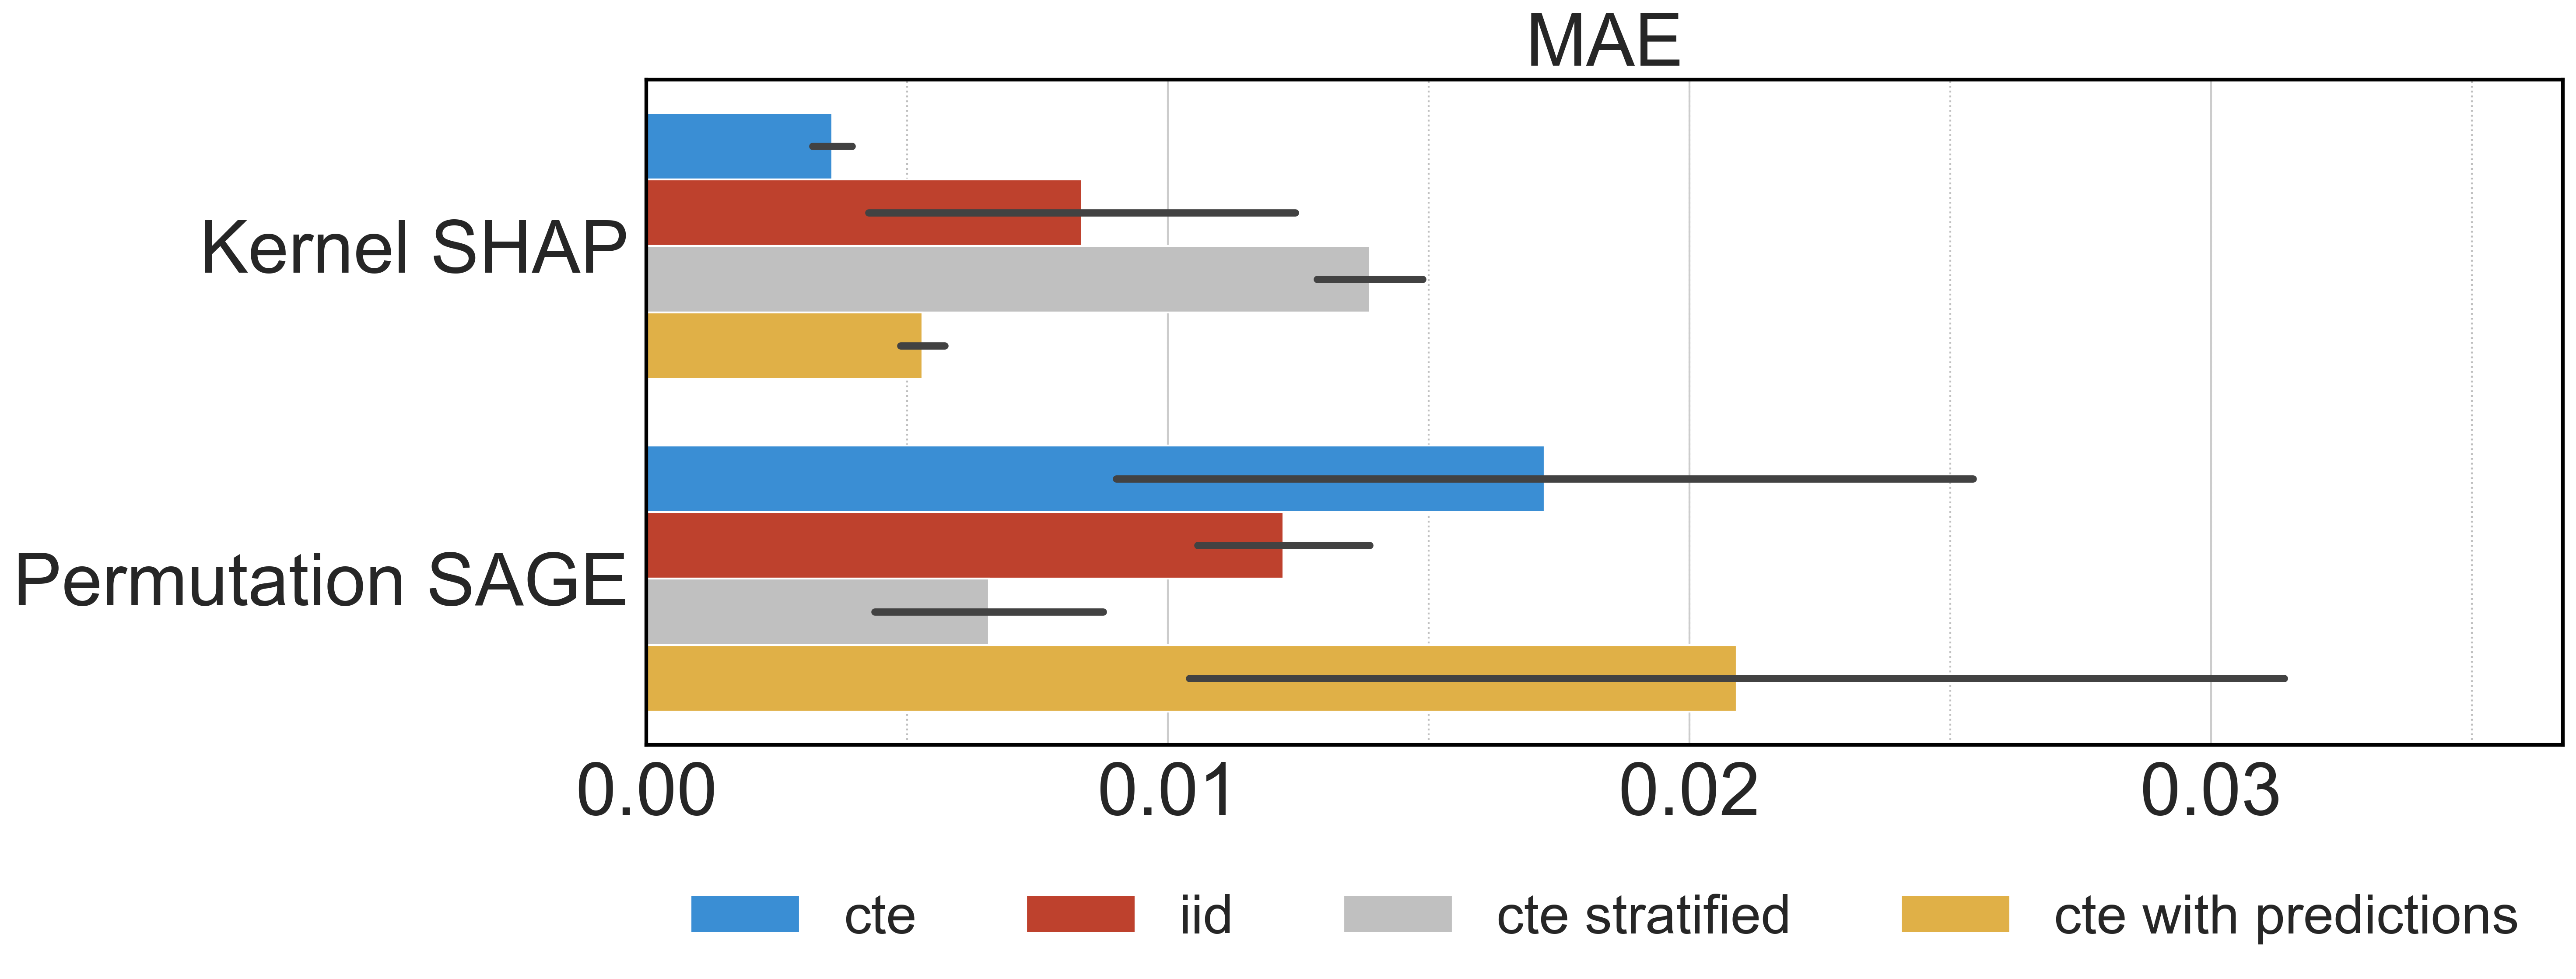

In [ ]:
sns.set_context("notebook", font_scale=1.6)
sns.set_style("whitegrid")

plt.figure(figsize=(20, 8), dpi=300)
ax = sns.barplot(
    y="explanation", x="mae", hue="method", data=plot_data,
    palette=custom_palette, errorbar="sd", zorder=2, errwidth=4
)

ax.set_title("MAE", fontsize=40)
ax.set_xlabel("", fontsize=28)
ax.set_ylabel("")
ax.tick_params(axis='x', labelsize=40)
ax.tick_params(axis='y', labelsize=40)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=30,
    frameon=False
)

xticks = ax.get_xticks()
if len(xticks) > 6:
    ax.set_xticks(xticks[::2])
for x in xticks:
    ax.axvline(x=x, color='gray', linestyle='dotted', linewidth=1, alpha=0.5, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

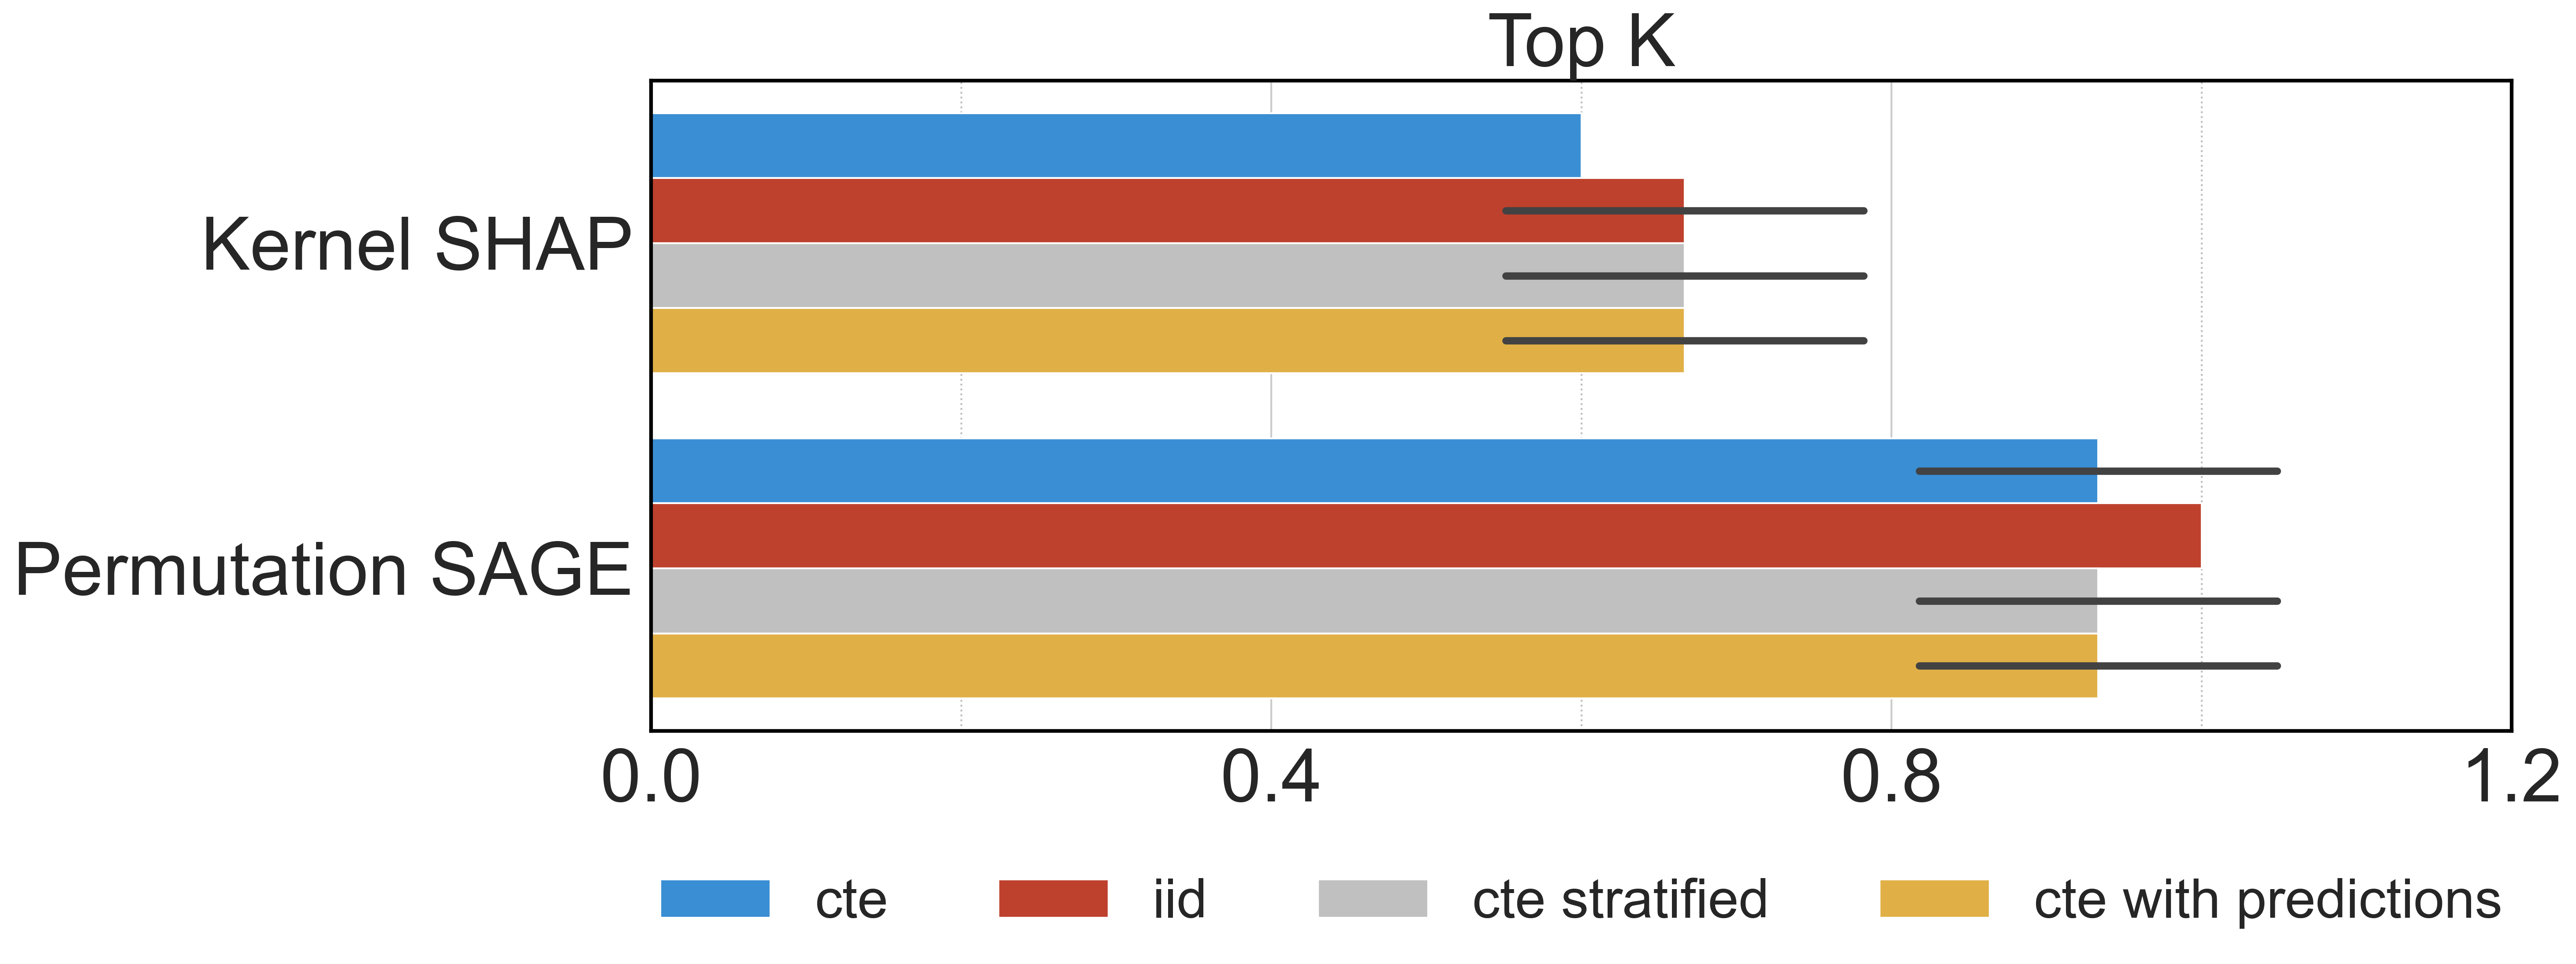

In [ ]:
sns.set_context("notebook", font_scale=2)
sns.set_style("whitegrid")

plt.figure(figsize=(20, 8), dpi=300)
ax = sns.barplot(
    y="explanation", x="top_k", hue="method", data=plot_data,
    palette=custom_palette, errorbar="sd", zorder=2, errwidth=4
)

ax.set_title("Top K", fontsize=40)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='x', labelsize=40)
ax.tick_params(axis='y', labelsize=40)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=30,
    frameon=False
)
ax.set_xlim(left=0)
xticks = ax.get_xticks()
if len(xticks) > 6:
    ax.set_xticks(xticks[::2])
for x in xticks:
    ax.axvline(x=x, color='gray', linestyle='dotted', linewidth=1, alpha=0.5, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
plt.tight_layout()
plt.show()

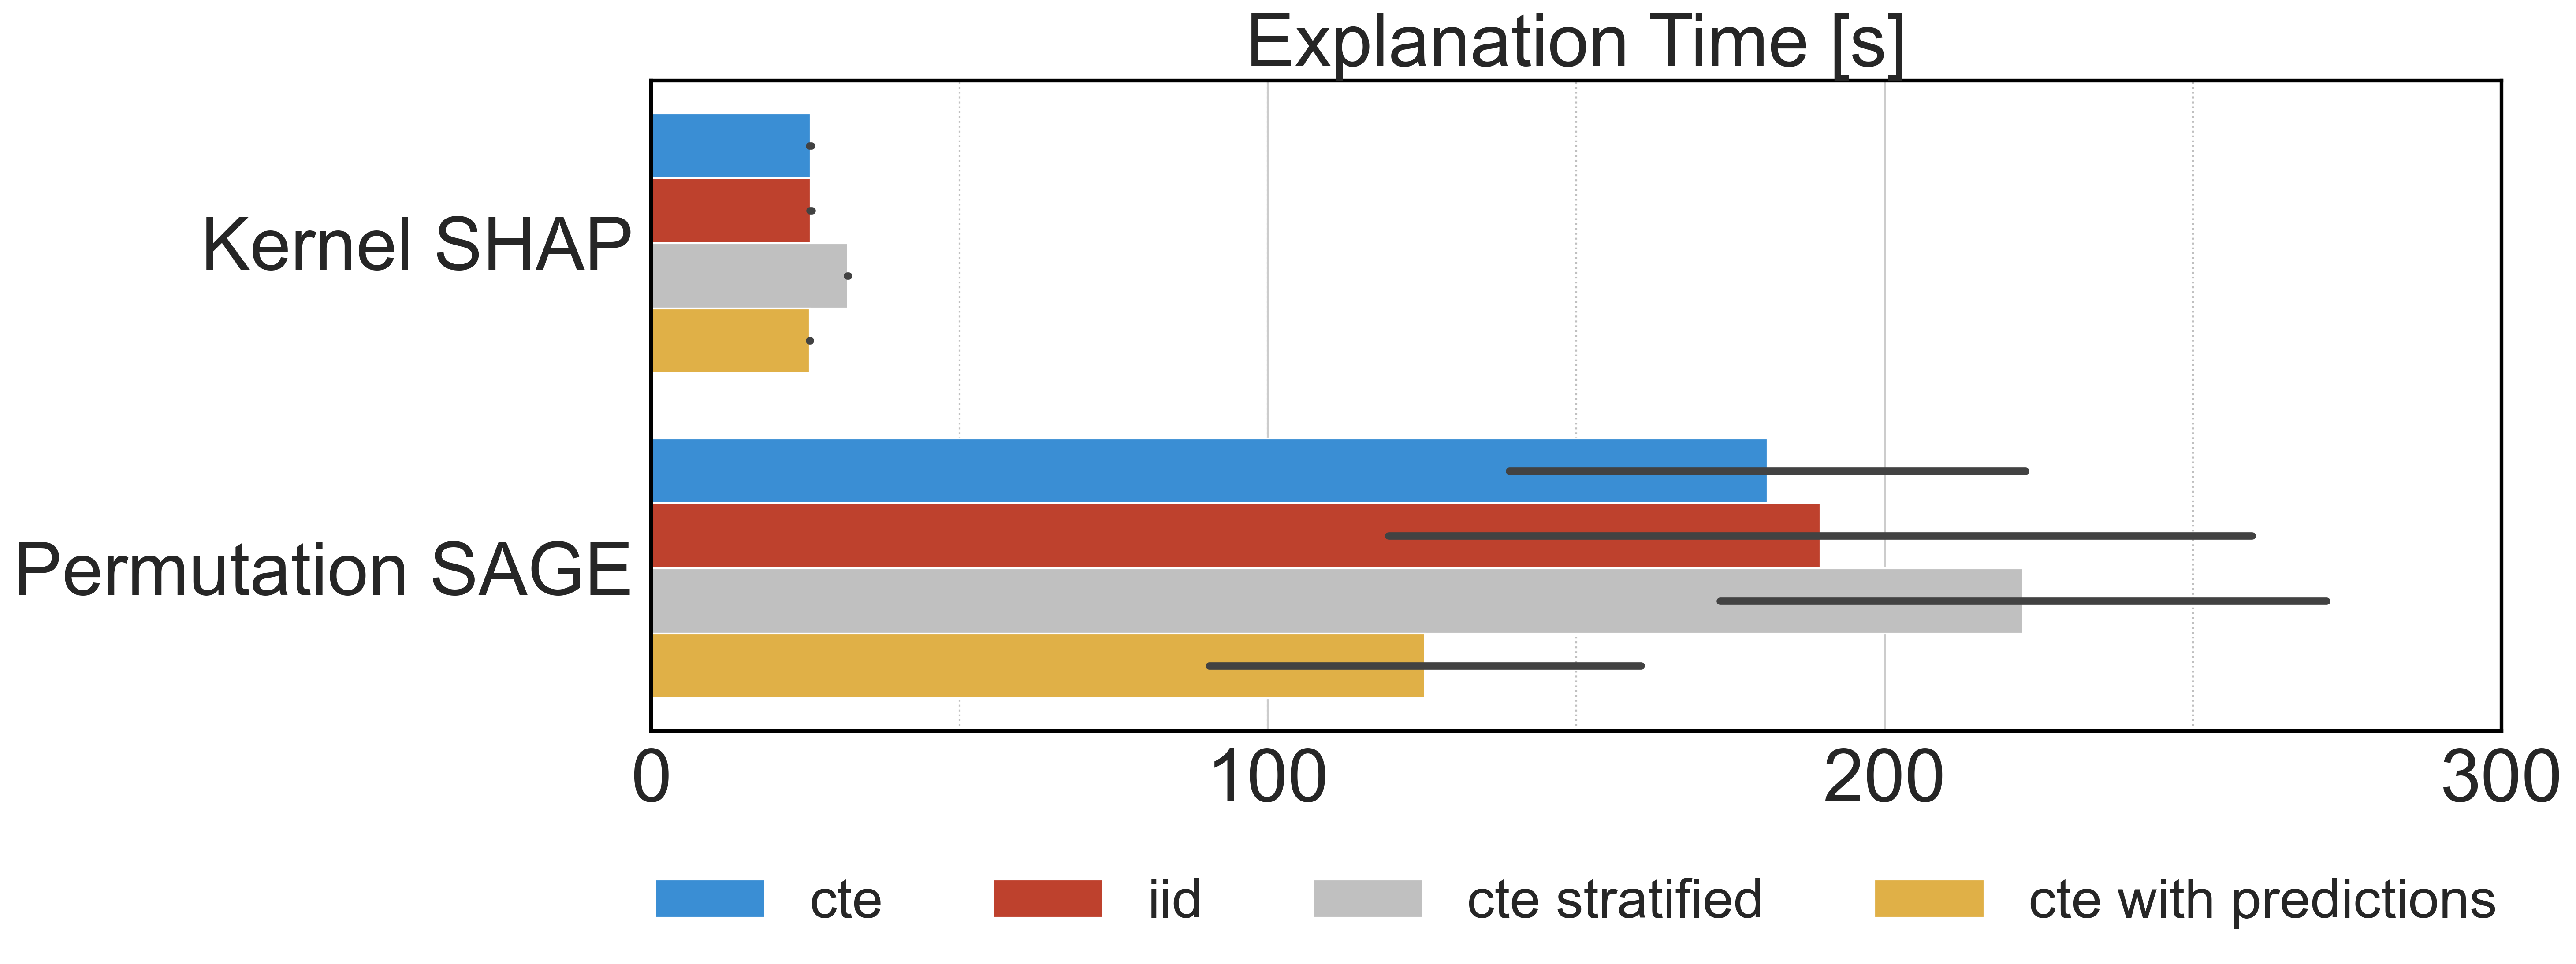

In [ ]:
plt.figure(figsize=(20, 8), dpi=300)
ax = sns.barplot(
    y="explanation", x="time_explanation", hue="method", data=plot_data,
    palette=custom_palette, errorbar="sd", zorder=2, errwidth=4
)

ax.set_title("Explanation Time [s]", fontsize=40)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='x', labelsize=40)
ax.tick_params(axis='y', labelsize=40)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=30,
    frameon=False
)
ax.set_xlim(left=0)
xticks = ax.get_xticks()
if len(xticks) > 6:
    ax.set_xticks(xticks[::2])
for x in xticks:
    ax.axvline(x=x, color='gray', linestyle='dotted', linewidth=1, alpha=0.5, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
plt.tight_layout()
plt.show()